<a href="https://colab.research.google.com/github/redgrave17/finalproject/blob/claude%2Faffectionate-allen-8eoaxi/eeg_dementia_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full Pipeline EEG Dementia Study

Dataset:
OpenNeuro **ds004504**: 88 subjects with Alzheimer's 36, FTD 23, control 29, plus MMSE).

| Stage | Components |
|-------|-----------|
| 1. Download | 88 EEGLAB `.set` files from OpenNeuro (~4 GB)
| 2. Features | MNE preprocess + 179 features/subject (all 88)
| 3. Classical CV | AD-vs-CN / DEM-vs-CN / 3-class / MMSE, subject-level
| 4. EEGNet | EEGNet-8,2 on raw epochs, GroupKFold by subject
| 5. Connectivity | per-band multilayer wPLI graphs + graph metrics
| 6. SMC-GCN | dynamic-FC sequences → particle-filter GNN + DynGCN
| 8. CAUEEG | external validation on the gated CAUEEG cohort



## Stage 0: install, imports, GPU check, config


In [ ]:
!pip -q install mne mne-connectivity networkx >/dev/null 2>&1
import os, sys, json, time, warnings, subprocess, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE,
      "(" + (torch.cuda.get_device_name(0) if DEVICE=="cuda" else "no GPU — enable Runtime>GPU for stages 4 & 6") + ")")

# ---- knobs (defaults tuned for a T4; raise for denser runs, lower for a quick smoke) ----
CFG = dict(
    N_SUB      = 88,      # subjects to download (88 = full)
    EEGNET_CAP = 80,      # windows/subject for EEGNet (None = use all; higher = slower, denser)
    EEGNET_EPOCHS = 40,   # EEGNet training epochs
    SMC_L      = 16,      # sub-sequence length (windows) for the dynamic-graph models
    SMC_K      = 8,       # sub-sequences per subject per training epoch
    SMC_EPOCHS = 40,      # SMC-GCN / DynGCN training epochs
    SMC_P      = 16,      # particles
    FOLDS      = 5,
)
DATA = "/content/ds004504"; RES = "/content/results"; os.makedirs(RES, exist_ok=True)
print("config:", CFG)


torch 2.11.0+cu128 | device: cuda (Tesla T4)
config: {'N_SUB': 88, 'EEGNET_CAP': 80, 'EEGNET_EPOCHS': 40, 'SMC_L': 16, 'SMC_K': 8, 'SMC_EPOCHS': 40, 'SMC_P': 16, 'FOLDS': 5}


## Stage 1: download ds004504 (88 subjects)


In [ ]:
BASE = "https://s3.amazonaws.com/openneuro.org/ds004504"
os.makedirs(DATA, exist_ok=True)
for f in ["participants.tsv", "participants.json", "dataset_description.json"]:
    subprocess.run(f'curl -fsS -o {DATA}/{f} {BASE}/{f}', shell=True)
ok = 0
for i in range(1, CFG["N_SUB"] + 1):
    sub = f"sub-{i:03d}"; d = f"{DATA}/{sub}/eeg"; os.makedirs(d, exist_ok=True)
    dst = f"{d}/{sub}_task-eyesclosed_eeg.set"
    if not os.path.exists(dst) or os.path.getsize(dst) == 0:
        subprocess.run(f'curl -fsS -o {dst} {BASE}/{sub}/eeg/{sub}_task-eyesclosed_eeg.set', shell=True)
    ok += os.path.exists(dst) and os.path.getsize(dst) > 0
    if i % 20 == 0: print("downloaded", i)
meta = pd.read_csv(f"{DATA}/participants.tsv", sep="\t").set_index("participant_id")
print(f"got {ok}/{CFG['N_SUB']} .set files | groups:", meta.Group.value_counts().to_dict())


downloaded 20
downloaded 40
downloaded 60
downloaded 80
got 88/88 .set files | groups: {'A': 36, 'C': 29, 'F': 23}


## Stage 2: preprocessing + 179 features per subject (all 88)
MNE: 0.5–45 Hz + 50 Hz notch, average reference, resample 128 Hz.
Features: relative band power, Hjorth, spectral entropy, connectivity (coh/wPLI), theta/alpha, alpha peak.


In [ ]:
import mne; mne.set_log_level("ERROR")
from mne_connectivity import spectral_connectivity_epochs
SF = 128.0
BANDS = {"delta":(.5,4),"theta":(4,8),"alpha":(8,13),"beta":(13,30),"gamma":(30,45)}
RENAME = {"T3":"T7","T4":"T8","T5":"P7","T6":"P8"}

def load_preprocess(p):
    r = mne.io.read_raw_eeglab(p, preload=True)
    r.rename_channels({k:v for k,v in RENAME.items() if k in r.ch_names})
    r.set_montage("standard_1020", on_missing="warn")
    r.notch_filter(50.0); r.filter(.5,45.0); r.set_eeg_reference("average"); r.resample(SF)
    return r

def make_epochs(r, overlap=0.5):
    e = mne.make_fixed_length_epochs(r, duration=4.0, overlap=4.0*overlap, preload=True)
    e.drop_bad(reject={"eeg":150e-6}); return e

def _hjorth(x):
    dx=np.diff(x,axis=-1); ddx=np.diff(dx,axis=-1); v0=x.var(-1)+1e-12; v1=dx.var(-1)+1e-12; v2=ddx.var(-1)+1e-12
    mob=np.sqrt(v1/v0); return v0.mean(0), mob.mean(0), (np.sqrt(v2/v1)/(mob+1e-12)).mean(0)

def _con_sum(e):
    o={}
    for b,(lo,hi) in [("theta",(4,8)),("alpha",(8,13)),("beta",(13,30))]:
        for meth in ("coh","wpli"):
            c=spectral_connectivity_epochs(e,method=meth,mode="multitaper",fmin=lo,fmax=hi,faverage=True,verbose=False)
            m=np.abs(c.get_data()).ravel(); m=m[m!=0]; o[f"{meth}_{b}_mean"]=float(m.mean()) if m.size else 0.0
    return o

def extract_features(e):
    ch=e.ch_names; sp=e.compute_psd(method="welch",fmin=.5,fmax=45,n_fft=int(SF*2))
    psd,fr=sp.get_data(return_freqs=True); tot=psd.sum(-1,keepdims=True)+1e-12
    F=[];N=[]
    for b,(lo,hi) in BANDS.items():
        idx=(fr>=lo)&(fr<hi); F.append((psd[:,:,idx].sum(-1,keepdims=True)/tot).squeeze(-1).mean(0)); N+=[f"relpow_{b}_{c}" for c in ch]
    X=e.get_data(); a,m,cx=_hjorth(X); F+=[a,m,cx]
    N+=[f"hjorth_activity_{c}" for c in ch]+[f"hjorth_mobility_{c}" for c in ch]+[f"hjorth_complexity_{c}" for c in ch]
    p=psd/(psd.sum(-1,keepdims=True)+1e-12); se=(-(p*np.log(p+1e-12)).sum(-1)).mean(0)/np.log(psd.shape[-1])
    F.append(se); N+=[f"specent_{c}" for c in ch]
    bm=lambda lo,hi: psd[:,:,(fr>=lo)&(fr<hi)].sum(-1).mean(); ai=(fr>=6)&(fr<=13)
    F.append(np.array([bm(4,8)/(bm(8,13)+1e-12), fr[ai][np.argmax(psd[:,:,ai].mean((0,1)))]])); N+=["theta_alpha_ratio","alpha_peak_hz"]
    cs=_con_sum(e); F.append(np.array(list(cs.values()))); N+=list(cs.keys())
    return np.concatenate([np.atleast_1d(f).ravel() for f in F]), N

rows=[]; t0=time.time()
subs=sorted(s for s in os.listdir(DATA) if s.startswith("sub-"))
for i,sub in enumerate(subs,1):
    sp=f"{DATA}/{sub}/eeg/{sub}_task-eyesclosed_eeg.set"
    if not os.path.exists(sp): continue
    try:
        fv,names=extract_features(make_epochs(load_preprocess(sp)))
        mrow=meta.loc[sub]; rows.append(dict(participant_id=sub,group=mrow.Group,Age=mrow.Age,MMSE=mrow.MMSE,**dict(zip(names,fv))))
        if i%15==0: print(f"  [{i}/{len(subs)}] {sub} ({time.time()-t0:.0f}s)")
    except Exception as ex: print(sub,"ERR",ex)
feats_df=pd.DataFrame(rows); feats_df.to_csv(f"{RES}/features.csv",index=False)
FEATCOLS=[c for c in feats_df.columns if c not in ("participant_id","group","Age","MMSE")]
print("features table", feats_df.shape, "| groups", feats_df.group.value_counts().to_dict())


  [15/88] sub-015 (126s)
  [30/88] sub-030 (226s)
  [45/88] sub-045 (348s)
  [60/88] sub-060 (457s)
  [75/88] sub-075 (548s)
features table (88, 183) | groups {'A': 36, 'C': 29, 'F': 23}


## Stage 3: classical ML, subject-level cross-validation
One recording per subject -> StratifiedKFold over subjects has no leakage.
5×10 repeated CV plus
permutation test
MMSE regression secondary.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict, KFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, recall_score, r2_score, mean_absolute_error

def models(k=30): return {
 "LogReg":Pipeline([("s",StandardScaler()),("k",SelectKBest(f_classif,k=k)),("c",LogisticRegression(max_iter=2000,class_weight="balanced"))]),
 "SVM":Pipeline([("s",StandardScaler()),("k",SelectKBest(f_classif,k=k)),("c",SVC(kernel="rbf",probability=True,class_weight="balanced"))]),
 "RF":Pipeline([("s",StandardScaler()),("c",RandomForestClassifier(n_estimators=400,class_weight="balanced",random_state=42))])}

def eval_bin(mask,pos,name):
    s=feats_df[mask].reset_index(drop=True); X=s[FEATCOLS].values
    y=s.group.isin(pos).astype(int).values if isinstance(pos,(list,tuple)) else (s.group==pos).astype(int).values
    cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=10,random_state=42); print(f"\n{name}: n={len(y)} pos={int(y.sum())}"); best=(0,None)
    for mn,pipe in models().items():
        A=[];B=[]
        for tr,te in cv.split(X,y):
            pipe.fit(X[tr],y[tr]); pr=pipe.predict_proba(X[te])[:,1]
            if len(set(y[te]))==2: A.append(roc_auc_score(y[te],pr))
            B.append(balanced_accuracy_score(y[te],(pr>=.5).astype(int)))
        print(f"  {mn:7s} AUC {np.mean(A):.3f}±{np.std(A):.3f} | bACC {np.mean(B):.3f}")
        if np.mean(A)>best[0]: best=(np.mean(A),mn)
    # permutation test on best model
    rng=np.random.default_rng(42); real=best[0]; null=[]; skf=StratifiedKFold(5,shuffle=True,random_state=42)
    for _ in range(200):
        yp=rng.permutation(y); a=[]
        for tr,te in skf.split(X,yp):
            if len(set(yp[te]))<2: continue
            a.append(roc_auc_score(yp[te],models()[best[1]].fit(X[tr],yp[tr]).predict_proba(X[te])[:,1]))
        null.append(np.mean(a))
    print(f"  permutation p (best={best[1]}, AUC {real:.3f}): p={(1+np.sum(np.array(null)>=real))/(1+len(null)):.4f}")
    return real

eval_bin(feats_df.group.isin(["A","C"]),"A","AD vs CN")
eval_bin(feats_df.group.isin(["A","F","C"]),["A","F"],"DEM(AD+FTD) vs CN")
eval_bin(feats_df.group.isin(["A","F"]),"A","AD vs FTD")
eval_bin(feats_df.group.isin(["F","C"]),"F","FTD vs CN")
# 3-class + MMSE
y3=feats_df.group.values
print("\n3-class A/F/C bACC:", round(balanced_accuracy_score(y3, cross_val_predict(models()["LogReg"],feats_df[FEATCOLS].values,y3,cv=StratifiedKFold(5,shuffle=True,random_state=42))),3))
mm=feats_df.dropna(subset=["MMSE"]); Xm=mm[FEATCOLS].values; ym=mm.MMSE.values.astype(float)
predm=cross_val_predict(Pipeline([("s",StandardScaler()),("r",RandomForestRegressor(400,random_state=42))]),Xm,ym,cv=KFold(5,shuffle=True,random_state=42))
print(f"MMSE (RF): R2={r2_score(ym,predm):.3f} MAE={mean_absolute_error(ym,predm):.2f}")



AD vs CN: n=65 pos=36
  LogReg  AUC 0.869±0.097 | bACC 0.818
  SVM     AUC 0.880±0.087 | bACC 0.798
  RF      AUC 0.858±0.096 | bACC 0.752
  permutation p (best=SVM, AUC 0.880): p=0.0050

DEM(AD+FTD) vs CN: n=88 pos=59
  LogReg  AUC 0.824±0.074 | bACC 0.723
  SVM     AUC 0.882±0.063 | bACC 0.739
  RF      AUC 0.876±0.064 | bACC 0.727
  permutation p (best=SVM, AUC 0.882): p=0.0050

AD vs FTD: n=59 pos=36
  LogReg  AUC 0.632±0.152 | bACC 0.600
  SVM     AUC 0.543±0.216 | bACC 0.545
  RF      AUC 0.615±0.163 | bACC 0.624
  permutation p (best=LogReg, AUC 0.632): p=0.0896

FTD vs CN: n=52 pos=23
  LogReg  AUC 0.787±0.136 | bACC 0.703
  SVM     AUC 0.837±0.108 | bACC 0.760
  RF      AUC 0.848±0.115 | bACC 0.735
  permutation p (best=RF, AUC 0.848): p=0.0050

3-class A/F/C bACC: 0.587
MMSE (RF): R2=0.225 MAE=4.23


## Stage 4: EEGNet-8,2 on raw epochs (subject-level GroupKFold)


In [ ]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupKFold
class MaxNorm(nn.Conv2d):
    def __init__(s,*a,mn=1.0,**k): super().__init__(*a,**k); s.mn=mn
    def forward(s,x):
        with torch.no_grad():
            n=torch.linalg.vector_norm(s.weight,dim=(1,2,3),keepdim=True).clamp(min=1e-8); s.weight.mul_(n.clamp(max=s.mn)/n)
        return super().forward(x)
class EEGNet(nn.Module):
    def __init__(s,nc=2,C=19,T=512,F1=8,D=2,F2=16,kl=64,p=0.5):
        super().__init__()
        s.b1=nn.Sequential(nn.Conv2d(1,F1,(1,kl),padding=(0,kl//2),bias=False),nn.BatchNorm2d(F1),
            MaxNorm(F1,F1*D,(C,1),groups=F1,bias=False),nn.BatchNorm2d(F1*D),nn.ELU(),nn.AvgPool2d((1,4)),nn.Dropout(p))
        s.b2=nn.Sequential(nn.Conv2d(F1*D,F1*D,(1,16),padding=(0,8),groups=F1*D,bias=False),
            nn.Conv2d(F1*D,F2,(1,1),bias=False),nn.BatchNorm2d(F2),nn.ELU(),nn.AvgPool2d((1,8)),nn.Dropout(p))
        s.fc=nn.Linear(F2*(T//32),nc)
    def forward(s,x): return s.fc(s.b2(s.b1(x)).flatten(1))

rng=np.random.default_rng(42); Xs,ys,gs=[],[],[]
for sub in sorted(s for s in os.listdir(DATA) if s.startswith("sub-")):
    g=meta.loc[sub,"Group"] if sub in meta.index else "NA"
    if g not in ("A","C"): continue
    try:
        e=make_epochs(load_preprocess(f"{DATA}/{sub}/eeg/{sub}_task-eyesclosed_eeg.set"),overlap=0.0)
        Xx=e.get_data()*1e6; cap=CFG["EEGNET_CAP"]
        if cap and len(Xx)>cap: Xx=Xx[rng.choice(len(Xx),cap,replace=False)]
        Xs.append(Xx.astype("float32")); ys.append(np.full(len(Xx),1 if g=="A" else 0)); gs.append(np.full(len(Xx),sub))
    except Exception as ex: print(sub,"skip",ex)
X=np.concatenate(Xs)[:,None]; y=np.concatenate(ys); grp=np.concatenate(gs)
print("epochs",X.shape,"from",len(set(grp)),"subjects")

def train_eegnet(Xtr,ytr,Xte,ep):
    net=EEGNet(T=X.shape[-1]).to(DEVICE); opt=torch.optim.Adam(net.parameters(),1e-3,weight_decay=1e-4)
    w=torch.tensor([1/((ytr==0).mean()+1e-6),1/((ytr==1).mean()+1e-6)],dtype=torch.float32); w=w/w.sum()*2
    lf=nn.CrossEntropyLoss(weight=w.to(DEVICE)); dl=DataLoader(TensorDataset(torch.from_numpy(Xtr),torch.from_numpy(ytr)),64,shuffle=True)
    net.train()
    for _ in range(ep):
        for xb,yb in dl: opt.zero_grad(); lf(net(xb.to(DEVICE)),yb.to(DEVICE)).backward(); opt.step()
    net.eval()
    with torch.no_grad(): return torch.softmax(net(torch.from_numpy(Xte).to(DEVICE)),1)[:,1].cpu().numpy()

st,sp=[],[]
for tr,te in GroupKFold(CFG["FOLDS"]).split(X,y,grp):
    mu=X[tr].mean((0,1,3),keepdims=True); sd=X[tr].std((0,1,3),keepdims=True)+1e-6
    pr=train_eegnet(((X[tr]-mu)/sd).astype("float32"),y[tr],((X[te]-mu)/sd).astype("float32"),CFG["EEGNET_EPOCHS"])
    for g in np.unique(grp[te]): m=grp[te]==g; sp.append(pr[m].mean()); st.append(int(y[te][m][0]))
st,sp=np.array(st),np.array(sp)
print(f"EEGNet AD-vs-CN (subject-level): AUC {roc_auc_score(st,sp):.3f} | bACC {balanced_accuracy_score(st,(sp>=.5).astype(int)):.3f}")


epochs (5143, 1, 19, 512) from 65 subjects
EEGNet AD-vs-CN (subject-level): AUC 0.937 | bACC 0.837


## Stage 5: per-band multilayer connectivity graphs + graph features
5-layer wPLI network per subject (delta→gamma) plus graph-theoretic features


In [ ]:
import networkx as nx
FMIN=(0.5,4,8,13,30); FMAX=(4,8,13,30,45); BN=["delta","theta","alpha","beta","gamma"]
def subject_graphs(sp):
    e=make_epochs(load_preprocess(sp)); n=len(e.ch_names)
    c=spectral_connectivity_epochs(e,method="wpli",mode="multitaper",fmin=FMIN,fmax=FMAX,faverage=True,verbose=False)
    dat=np.abs(c.get_data()); A=np.zeros((5,n,n))
    for b in range(5):
        M=dat[:,b].reshape(n,n); M=M+M.T; np.fill_diagonal(M,0); A[b]=M
    return A
def _thr(M,keep=0.30):
    n=M.shape[0]; iu=np.triu_indices(n,1); w=M[iu]; k=max(1,int(round(keep*w.size))); thr=np.sort(w)[-k]
    T=np.where(M>=thr,M,0.0); np.fill_diagonal(T,0); return T
def gmetrics(M):
    strg=M.sum(1); Mt=_thr(M); G=nx.from_numpy_array(Mt); D=Mt.copy(); nz=D>0; D[nz]=1/D[nz]
    try: ge=nx.global_efficiency(nx.from_numpy_array(D))
    except: ge=np.nan
    try: cl=nx.average_clustering(G,weight="weight")
    except: cl=np.nan
    try: comms=nx.community.greedy_modularity_communities(G,weight="weight"); mo=nx.community.modularity(G,comms,weight="weight")
    except: mo=np.nan
    return dict(mean_strength=float(strg.mean()),strength_std=float(strg.std()),clustering=float(cl),global_eff=float(ge),modularity=float(mo))
grows=[]
for i,sub in enumerate(sorted(s for s in os.listdir(DATA) if s.startswith("sub-")),1):
    try:
        A=subject_graphs(f"{DATA}/{sub}/eeg/{sub}_task-eyesclosed_eeg.set")
        f={"participant_id":sub,"group":meta.loc[sub,"Group"]}
        for b,nm in enumerate(BN):
            for k,v in gmetrics(A[b]).items(): f[f"g_{nm}_{k}"]=v
        iu=np.triu_indices(A.shape[1],1)
        for a in range(5):
            for cc in range(a+1,5):
                r=np.corrcoef(A[a][iu],A[cc][iu])[0,1]; f[f"xlayer_{BN[a]}_{BN[cc]}"]=float(r if r==r else 0)
        grows.append(f)
        if i%20==0: print("  graphs",i)
    except Exception as ex: print(sub,"ERR",ex)
graph_df=pd.DataFrame(grows); GCOLS=[c for c in graph_df.columns if c.startswith(("g_","xlayer_"))]
mg=feats_df.merge(graph_df[["participant_id"]+GCOLS],on="participant_id")
print("graph features:",len(GCOLS))
for name,pos,mask in [("AD_vs_CN","A",mg.group.isin(["A","C"])),("AD_vs_FTD","A",mg.group.isin(["A","F"])),("FTD_vs_CN","F",mg.group.isin(["F","C"]))]:
    s=mg[mask].reset_index(drop=True); y=(s.group==pos).astype(int).values; cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=10,random_state=42)
    def auc(cols):
        X=s[cols].values; A=[]
        for tr,te in cv.split(X,y):
            p=Pipeline([("s",StandardScaler()),("k",SelectKBest(f_classif,k=min(30,X.shape[1]))),("c",SVC(kernel="rbf",probability=True,class_weight="balanced"))]).fit(X[tr],y[tr])
            if len(set(y[te]))==2: A.append(roc_auc_score(y[te],p.predict_proba(X[te])[:,1]))
        return np.mean(A)
    print(f"  {name}: base {auc(FEATCOLS):.3f} | graph {auc(GCOLS):.3f} | base+graph {auc(FEATCOLS+GCOLS):.3f}")


  graphs 20
  graphs 40
  graphs 60
  graphs 80
graph features: 35
  AD_vs_CN: base 0.880 | graph 0.750 | base+graph 0.880
  AD_vs_FTD: base 0.597 | graph 0.451 | base+graph 0.625
  FTD_vs_CN: base 0.837 | graph 0.724 | base+graph 0.853


## Stage 6: dynamic FC → SMC-GCN particle filter + DynGCN
Sliding-window alpha-AEC graph sequences fed to a graph-state particle filter and a deterministic dynamic-GCN baseline.
Subsequence-augmented subject-level GroupKFold.


In [ ]:
from scipy.signal import hilbert
DBANDS=[("delta",.5,4),("theta",4,8),("alpha",8,13),("beta",13,30),("gamma",30,45)]; ADJ=2
def dynamic_fc(sp, win_s=16.0, step_s=8.0):
    r=load_preprocess(sp); x=r.get_data(); sf=r.info["sfreq"]; nch,nt=x.shape
    env=np.zeros((5,nch,nt))
    for b,(nm,lo,hi) in enumerate(DBANDS): env[b]=np.abs(hilbert(mne.filter.filter_data(x,sf,lo,hi,verbose=False),axis=1))
    win,step=int(win_s*sf),int(step_s*sf); A_seq,X_seq=[],[]
    for s in range(0,nt-win+1,step):
        sl=slice(s,s+win); e=env[ADJ][:,sl]; A=np.abs(np.nan_to_num(np.corrcoef(e))); np.fill_diagonal(A,0)
        A_seq.append(A.astype("float32")); X_seq.append(np.log(env[:,:,sl].mean(2)+1e-12).T.astype("float32"))
    return np.array(A_seq),np.array(X_seq)
A_list,X_list,yd,subj=[],[],[],[]
for sub in sorted(s for s in os.listdir(DATA) if s.startswith("sub-")):
    g=meta.loc[sub,"Group"] if sub in meta.index else "NA"
    if g not in ("A","C"): continue
    try: A,Xf=dynamic_fc(f"{DATA}/{sub}/eeg/{sub}_task-eyesclosed_eeg.set"); A_list.append(A); X_list.append(Xf); yd.append(1 if g=="A" else 0); subj.append(sub)
    except Exception as ex: print(sub,"ERR",ex)
yd=np.array(yd); subj=np.array(subj); print(len(yd),"subjects; window range",min(a.shape[0] for a in A_list),"-",max(a.shape[0] for a in A_list))

def _norm_adj(A):
    B,N,_=A.shape; I=torch.eye(N,device=A.device).unsqueeze(0); Ah=A+I; d=Ah.sum(-1).clamp(min=1e-6).pow(-0.5)
    return d.unsqueeze(-1)*Ah*d.unsqueeze(1)
class SMCGCN(nn.Module):
    def __init__(s,N=19,ind=5,d=16,P=16,nc=2,alpha=0.5,ess=0.5,p=0.3):
        super().__init__(); s.N,s.d,s.P,s.alpha,s.ess=N,d,P,alpha,ess
        s.enc=nn.Linear(ind,d); s.trans=nn.Linear(d,d)
        s.lp=nn.Parameter(torch.tensor(-2.0)); s.lo=nn.Parameter(torch.tensor(0.0)); s.dec=nn.Parameter(torch.tensor(1.0))
        s.head=nn.Sequential(nn.Linear(d,d),nn.ReLU(),nn.Dropout(p),nn.Linear(d,nc))
    def forward(s,A_seq,X_seq):
        B,T=A_seq.shape[0],A_seq.shape[1]
        z=torch.tanh(s.enc(X_seq[:,0]).unsqueeze(1).expand(-1,s.P,-1,-1)).contiguous()+0.1*torch.randn(B,s.P,s.N,s.d,device=A_seq.device)
        logw=torch.full((B,s.P),-np.log(s.P),device=A_seq.device)
        for t in range(T):
            Ah=_norm_adj(A_seq[:,t])
            z=torch.tanh(torch.einsum("bnm,bpmd->bpnd",Ah,s.trans(z))+s.enc(X_seq[:,t]).unsqueeze(1))+torch.exp(s.lp)*torch.randn_like(z)
            Ahat=torch.tanh(s.dec*torch.einsum("bpnd,bpmd->bpnm",z,z)/(s.d**0.5))
            logw=logw+(-0.5*((A_seq[:,t].unsqueeze(1)-Ahat)**2).sum((-1,-2))/torch.exp(s.lo).clamp(min=1e-3))
            logw=logw-torch.logsumexp(logw,1,keepdim=True)
            if (1.0/(torch.softmax(logw,1)**2).sum(1) < s.ess*s.P).any():
                w=torch.softmax(logw,1); q=s.alpha*w+(1-s.alpha)/s.P; idx=torch.multinomial(q,s.P,replacement=True)
                z=torch.gather(z,1,idx.unsqueeze(-1).unsqueeze(-1).expand(-1,-1,s.N,s.d))
                wn=torch.gather(w,1,idx)/(s.P*torch.gather(q,1,idx)+1e-12); logw=torch.log(wn+1e-12); logw=logw-torch.logsumexp(logw,1,keepdim=True)
        w=torch.softmax(logw,1).unsqueeze(-1).unsqueeze(-1); return s.head((w*z).sum(1).mean(1))
class DynGCN(nn.Module):
    def __init__(s,N=19,ind=5,d=16,nc=2,p=0.3):
        super().__init__(); s.enc=nn.Linear(ind,d); s.trans=nn.Linear(d,d); s.head=nn.Sequential(nn.Linear(d,d),nn.ReLU(),nn.Dropout(p),nn.Linear(d,nc))
    def forward(s,A_seq,X_seq):
        z=torch.tanh(s.enc(X_seq[:,0]))
        for t in range(A_seq.shape[1]):
            Ah=_norm_adj(A_seq[:,t]); z=torch.tanh(torch.einsum("bnm,bmd->bnd",Ah,s.trans(z))+s.enc(X_seq[:,t]))
        return s.head(z.mean(1))

allX=np.concatenate([x.reshape(-1,x.shape[-1]) for x in X_list]); mu,sd=allX.mean(0),allX.std(0)+1e-6
def subseq(A,X,L,starts): return np.stack([A[s:s+L] for s in starts]),np.stack([X[s:s+L] for s in starts])
def run(kind):
    L,K,P=CFG["SMC_L"],CFG["SMC_K"],CFG["SMC_P"]; rng=np.random.default_rng(0); st,sp=[],[]
    for tr,te in GroupKFold(CFG["FOLDS"]).split(np.arange(len(yd)),yd,groups=subj):
        net=(SMCGCN(P=P) if kind=="smc" else DynGCN()).to(DEVICE)
        opt=torch.optim.Adam(net.parameters(),3e-3,weight_decay=1e-3)
        w=torch.tensor([1/max(1,(yd[tr]==0).sum()),1/max(1,(yd[tr]==1).sum())],dtype=torch.float32); w=w/w.sum()*2
        lf=nn.CrossEntropyLoss(weight=w.to(DEVICE))
        for ep in range(CFG["SMC_EPOCHS"]):
            net.train(); bA,bX,bY=[],[],[]
            for i in rng.permutation(tr):
                T=A_list[i].shape[0]; sts=[0]*K if T<=L else rng.integers(0,T-L,size=K).tolist()
                a,x=subseq(A_list[i],X_list[i],L,sts); bA.append(a); bX.append((x-mu)/sd); bY+=[yd[i]]*len(sts)
            A=torch.tensor(np.concatenate(bA),dtype=torch.float32); X=torch.tensor(np.concatenate(bX),dtype=torch.float32); Y=torch.tensor(bY)
            perm=torch.randperm(len(Y))
            for b in range(0,len(Y),16):
                sl=perm[b:b+16]; opt.zero_grad(); loss=lf(net(A[sl].to(DEVICE),X[sl].to(DEVICE)),Y[sl].to(DEVICE)); loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(),5.0); opt.step()
        net.eval()
        with torch.no_grad():
            for i in te:
                T=A_list[i].shape[0]; sts=[0] if T<=L else np.linspace(0,T-L,5).astype(int).tolist()
                a,x=subseq(A_list[i],X_list[i],L,sts)
                p=torch.softmax(net(torch.tensor(a,dtype=torch.float32).to(DEVICE),torch.tensor((x-mu)/sd,dtype=torch.float32).to(DEVICE)),1)[:,1].mean().item()
                sp.append(p); st.append(int(yd[i]))
    st,sp=np.array(st),np.array(sp); return roc_auc_score(st,sp),balanced_accuracy_score(st,(sp>=.5).astype(int))
for kind in ("dyn","smc"):
    auc,bacc=run(kind); print(f"{kind.upper():6s} AD-vs-CN: AUC {auc:.3f} | bACC {bacc:.3f}")
print("(compare to static spectral SVM AUC ~0.88 from Stage 3)")


65 subjects; window range 37 - 160
DYN    AD-vs-CN: AUC 0.798 | bACC 0.754
SMC    AD-vs-CN: AUC 0.787 | bACC 0.789
(compare to static spectral SVM AUC ~0.88 from Stage 3)


## Stage 6b: Robustness (P2): learning curve + cross-endpoint transfer

Two cheap analyses that partly offset the single-cohort limitation and directly answer a reviewer:
- **Learning curve**: AUC vs training-set size
- **Cross-endpoint transfer**: train the model to separate **AD vs CN only**, then, without ever
  training on FTD, score FTD subjects. If FTD scores like AD (higher than CN), the EEG impairment signal generalises across dementia types, an internal proxy for out-of-distribution validity.
Both are leakage-safe (held-out CN are scored as test, FTD are never in training).


Learning curve (AD vs CN):
  n=26 (40%): AUC 0.783 ± 0.074
  n=36 (55%): AUC 0.826 ± 0.066
  n=46 (70%): AUC 0.859 ± 0.059
  n=55 (85%): AUC 0.866 ± 0.037
  n=65 (100%): AUC 0.856 ± 0.002


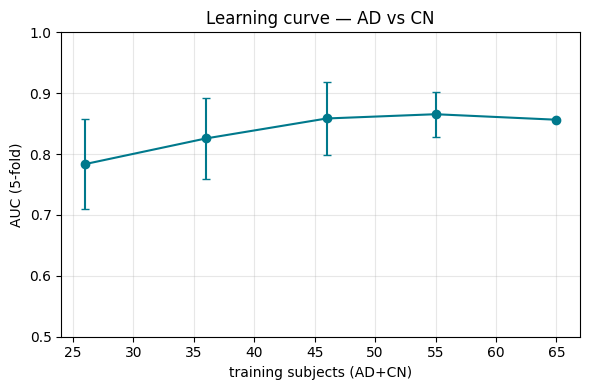

  tail slope: -0.009 AUC -> near saturation

Cross-endpoint transfer (train AD-vs-CN, score FTD without training on it):
  mean 'impairment' score:  CN 0.30 | FTD 0.60 | AD 0.74
  cross-endpoint AUC (AD-trained model separates FTD from CN): 0.804
  -> FTD scoring above CN = the EEG impairment signal transfers across dementia types


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
adcn = feats_df[feats_df.group.isin(["A","C"])].reset_index(drop=True)
Xa = adcn[FEATCOLS].values; ya = (adcn.group == "A").astype(int).values
def _svm():
    return Pipeline([("s",StandardScaler()),("k",SelectKBest(f_classif,k=30)),
                     ("c",SVC(kernel="rbf",probability=True,class_weight="balanced"))])

# ---------- (a) learning curve: AUC vs number of training subjects ----------
print("Learning curve (AD vs CN):")
fracs=[0.4,0.55,0.7,0.85,1.0]; ns=[]; means=[]; sds=[]
for fr in fracs:
    if fr>=1.0: reps=[np.arange(len(ya))]*8
    else: reps=[tr for tr,_ in StratifiedShuffleSplit(n_splits=8,train_size=fr,random_state=0).split(Xa,ya)]
    aucs=[]
    for idx in reps:
        Xi,yi=Xa[idx],ya[idx]
        if len(np.unique(yi))<2: continue
        pr=cross_val_predict(_svm(),Xi,yi,cv=StratifiedKFold(5,shuffle=True,random_state=1),method="predict_proba")[:,1]
        aucs.append(roc_auc_score(yi,pr))
    ns.append(int(round(fr*len(ya)))); means.append(float(np.mean(aucs))); sds.append(float(np.std(aucs)))
    print(f"  n={ns[-1]:2d} ({fr:.0%}): AUC {means[-1]:.3f} ± {sds[-1]:.3f}")
means=np.array(means); sds=np.array(sds)
plt.figure(figsize=(6,4)); plt.errorbar(ns,means,yerr=sds,marker="o",capsize=3,color="#00798c")
plt.xlabel("training subjects (AD+CN)"); plt.ylabel("AUC (5-fold)"); plt.ylim(0.5,1.0)
plt.title("Learning curve — AD vs CN"); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(f"{RES}/fig_learning_curve.png",dpi=150); plt.show()
slope=means[-1]-means[-2]
print(f"  tail slope: {slope:+.3f} AUC ->", "still rising (more data would help)" if slope>0.01 else "near saturation")

# ---------- (b) cross-endpoint transfer: AD-trained model scores FTD ----------
print("\nCross-endpoint transfer (train AD-vs-CN, score FTD without training on it):")
ftd = feats_df[feats_df.group=="F"].reset_index(drop=True); Xf = ftd[FEATCOLS].values
cn_s=[]; ad_s=[]; ftd_acc=np.zeros(len(ftd)); nf=0
for tr,te in StratifiedKFold(5,shuffle=True,random_state=42).split(Xa,ya):
    m=_svm().fit(Xa[tr],ya[tr]); pr=m.predict_proba(Xa[te])[:,1]
    for j,i in enumerate(te): (ad_s if ya[i]==1 else cn_s).append(pr[j])   # held-out CN/AD scores
    ftd_acc += m.predict_proba(Xf)[:,1]; nf+=1                             # FTD never in training
ftd_sc=ftd_acc/nf; cn_sc=np.array(cn_s); ad_sc=np.array(ad_s)
yt=np.r_[np.ones(len(ftd_sc)),np.zeros(len(cn_sc))]; ss=np.r_[ftd_sc,cn_sc]
print(f"  mean 'impairment' score:  CN {cn_sc.mean():.2f} | FTD {ftd_sc.mean():.2f} | AD {ad_sc.mean():.2f}")
print(f"  cross-endpoint AUC (AD-trained model separates FTD from CN): {roc_auc_score(yt,ss):.3f}")
print("  -> FTD scoring above CN = the EEG impairment signal transfers across dementia types")


## Stage 7: summary figure


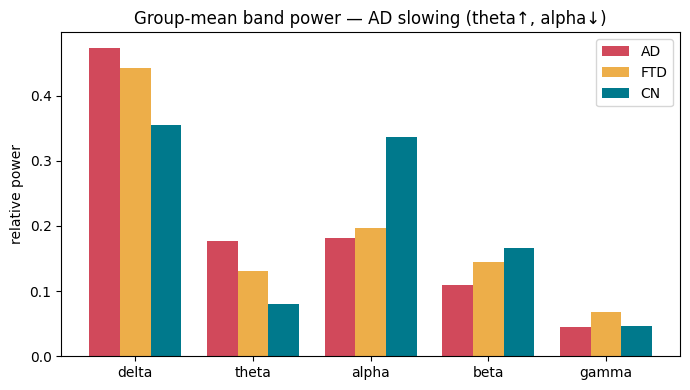

In [ ]:
import matplotlib.pyplot as plt
GN={"A":"AD","F":"FTD","C":"CN"}; GC={"A":"#d1495b","F":"#edae49","C":"#00798c"}; BANDL=list(BANDS)
fig,ax=plt.subplots(figsize=(7,4)); x=np.arange(len(BANDL)); wd=0.26
for i,g in enumerate(["A","F","C"]):
    vals=[feats_df[feats_df.group==g][[c for c in FEATCOLS if c.startswith(f"relpow_{b}_")]].values.mean() for b in BANDL]
    ax.bar(x+(i-1)*wd,vals,wd,label=GN[g],color=GC[g])
ax.set_xticks(x); ax.set_xticklabels(BANDL); ax.set_ylabel("relative power"); ax.legend(); ax.set_title("Group-mean band power — AD slowing (theta↑, alpha↓)")
plt.tight_layout(); plt.savefig(f"{RES}/fig_bandpower.png",dpi=150); plt.show()


## Stage 8: External validation on CAUEEG

A genuinely independent second site (Chung-Ang University Hospital; Kim et al. 2023, ~1,379 resting
EDFs, Normal/MCI/Dementia). CAUEEG is **access-gated and not downloadable**, point `CAUEEG_PATH` at the folder containing `dementia.json` and
`signal/edf/`. If it is not found the stage prints a notice and is skipped, so Run-all still
completes. CAUEEG is mapped onto the identical 179 features (60 Hz notch for Korean mains, same
legacy→standard channel rename), then within-site official subject-disjoint split, AHEPA→CAUEEG
transfer (fit ds004504, apply unchanged), and optional ComBat site-harmonisation.


In [ ]:
import os, glob, shutil, time
from google.colab import drive
drive.mount("/content/drive")
SRC = next((c for c in [
    "/content/drive/MyDrive/nhnh/eeg/caueeg-dataset/caueeg-dataset",
    "/content/drive/MyDrive/eeg/caueeg-dataset/caueeg-dataset"]
    if os.path.exists(f"{c}/dementia.json")), None)
assert SRC, "CAUEEG not found on Drive"
LOCAL = "/content/caueeg"; os.makedirs(f"{LOCAL}/signal/edf", exist_ok=True)
shutil.copy(f"{SRC}/dementia.json", f"{LOCAL}/dementia.json")
src = sorted(glob.glob(f"{SRC}/signal/edf/*.edf"))
print(f"staging {len(src)} EDFs Drive->local ...")
done = 0
for i, e in enumerate(src, 1):
    d = f"{LOCAL}/signal/edf/{os.path.basename(e)}"
    if os.path.exists(d) and os.path.getsize(d) > 0: done += 1; continue
    for _ in range(5):
        try: shutil.copy(e, d); done += 1; break
        except OSError:                                   # mount dropped -> revive and retry
            drive.mount("/content/drive", force_remount=True); time.sleep(2)
    if i % 300 == 0: print(f"  {i}/{len(src)} (ok={done})")
print(f"staged {done}/{len(src)} EDFs -> {LOCAL}")

Mounted at /content/drive
staging 1379 EDFs Drive->local ...
Mounted at /content/drive
  300/1379 (ok=300)
  600/1379 (ok=600)
  900/1379 (ok=900)
  1200/1379 (ok=1200)
staged 1379/1379 EDFs -> /content/caueeg


In [ ]:
CAUEEG_PATH  = "/content/caueeg"     # local copy — fast + reliable, no Drive during extraction
CAUEEG_LIMIT = None    # None = all labelled recordings; set e.g. 100 for a quick smoke test

if CAUEEG_PATH.startswith("/content/drive"):
    try:
        from google.colab import drive; drive.mount("/content/drive")
    except Exception as _e: print("drive mount:", _e)

import glob as _glob
# resolve the path: try the given one, then a few common locations (folder must hold dementia.json + signal/edf)
_cands = [CAUEEG_PATH,
          "/content/drive/MyDrive/nhnh/eeg/caueeg-dataset/caueeg-dataset",
          "/content/drive/MyDrive/eeg/caueeg-dataset/caueeg-dataset",
          "/content/drive/MyDrive/caueeg-dataset/caueeg-dataset"]
CAUEEG_PATH = next((c for c in _cands if os.path.exists(f"{c}/dementia.json")), CAUEEG_PATH)

if not (os.path.isdir(CAUEEG_PATH) and os.path.exists(f"{CAUEEG_PATH}/dementia.json")):
    print(f"CAUEEG not found at {CAUEEG_PATH} — skipping external validation (gated dataset).")
    print("To enable: set CAUEEG_PATH to the folder with dementia.json + signal/edf/.")
else:
    print("using CAUEEG at:", CAUEEG_PATH)
    from sklearn.metrics import recall_score
    # --- CAUEEG loader: 19 canonical channels, SAME rename as ds004504 (T3->T7 ...), 60 Hz notch ---
    CANON19 = ["Fp1","Fp2","F3","F4","C3","C4","P3","P4","O1","O2","F7","F8","T3","T4","T5","T6","Fz","Cz","Pz"]
    def load_caueeg_edf(p):
        r = mne.io.read_raw_edf(p, preload=True, verbose=False)
        r.rename_channels({c: c.split("-")[0] for c in r.ch_names})                       # strip '-AVG'
        r.rename_channels({k:v for k,v in {"FZ":"Fz","CZ":"Cz","PZ":"Pz"}.items() if k in r.ch_names})
        drop=[c for c in r.ch_names if c not in CANON19]                                   # EKG, Photic, extras
        if drop: r.drop_channels(drop)
        if sum(c in r.ch_names for c in CANON19) < 19: raise ValueError("missing canonical channels")
        r.pick_channels(CANON19, ordered=True)
        r.rename_channels({k:v for k,v in RENAME.items() if k in r.ch_names})              # -> T7/T8/P7/P8, match feats_df
        r.set_montage("standard_1020", on_missing="warn")
        r.notch_filter(60.0); r.filter(0.5,45.0); r.set_eeg_reference("average"); r.resample(SF)
        return r
    # --- labels from dementia.json (0 Normal->C, 1 MCI->M, 2 Dementia->A) + official split ---
    _dj=json.load(open(f"{CAUEEG_PATH}/dementia.json")); _nm=[n.lower() for n in _dj.get("class_label_to_name",["normal","mci","dementia"])]
    _to_ac=lambda ci: "A" if "dementia" in _nm[ci] else ("C" if "normal" in _nm[ci] else "M")
    calab={}; csplit={}
    for sp in ("train_split","validation_split","test_split"):
        for rec in _dj.get(sp,[]) or []:
            s=str(rec.get("serial","")).zfill(5); calab[s]=_to_ac(int(rec["class_label"])); csplit[s]=sp
    edfs=[e for e in sorted(_glob.glob(f"{CAUEEG_PATH}/signal/edf/*.edf"))
          if calab.get(os.path.splitext(os.path.basename(e))[0].zfill(5)) in ("A","C","M")]
    if CAUEEG_LIMIT: edfs=edfs[:CAUEEG_LIMIT]
    print(f"CAUEEG: extracting features for {len(edfs)} labelled recordings (~{max(1,len(edfs)*2//60)} min)...")
    crows=[]; t0=time.time()
    for i,edf in enumerate(edfs,1):
        s=os.path.splitext(os.path.basename(edf))[0].zfill(5)
        try:
            fv,names=extract_features(make_epochs(load_caueeg_edf(edf)))
            crows.append(dict(participant_id=f"caueeg-{s}",group=calab[s],split=csplit.get(s,""),**dict(zip(names,fv))))
        except Exception as ex:
            if i<5 or i%100==0: print(f"  {s}: ERR {ex}")
        if i%100==0: print(f"  [{i}/{len(edfs)}] {time.time()-t0:.0f}s")
    caueeg_df=pd.DataFrame(crows); caueeg_df.to_csv(f"{RES}/mc_features_caueeg.csv",index=False)
    print("CAUEEG table:",caueeg_df.shape,"| groups",caueeg_df.group.value_counts().to_dict())

    # --- external validation (subject-level; SVC seed=42 for a reproducible operating point) ---
    def _svm_ev(): return Pipeline([("s",StandardScaler()),("k",SelectKBest(f_classif,k=30)),
        ("c",SVC(kernel="rbf",probability=True,class_weight="balanced",random_state=42))])
    CF=[c for c in FEATCOLS if c in caueeg_df.columns]
    def _m(y,pr):
        p=(pr>=.5).astype(int)
        return dict(n=int(len(y)),auc=float(roc_auc_score(y,pr)),bacc=float(balanced_accuracy_score(y,p)),
                    sens=float(recall_score(y,p,pos_label=1,zero_division=0)),spec=float(recall_score(y,p,pos_label=0,zero_division=0)))
    cext={}; ac=caueeg_df[caueeg_df.group.isin(["A","C"])].reset_index(drop=True)
    Xc=ac[CF].values; yc=(ac.group=="A").astype(int).values
    tr=ac[ac.split=="train_split"]; te=ac[ac.split.isin(["validation_split","test_split"])]
    if len(te)>10 and te.group.nunique()==2:
        m=_svm_ev().fit(tr[CF].values,(tr.group=="A").astype(int).values)
        cext["within_official_split"]=_m((te.group=="A").astype(int).values,m.predict_proba(te[CF].values)[:,1]); r=cext["within_official_split"]
        print(f"\n[within CAUEEG, official subject-disjoint split] n={r['n']}  AUC {r['auc']:.3f} | bACC {r['bacc']:.3f} | sens {r['sens']:.3f} | spec {r['spec']:.3f}")
    cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=10,random_state=42); A=[a for a in
        (roc_auc_score(yc[b],_svm_ev().fit(Xc[a2],yc[a2]).predict_proba(Xc[b])[:,1]) for a2,b in cv.split(Xc,yc))]
    cext["within_cv_auc"]=float(np.mean(A)); print(f"[within CAUEEG, 5x10 CV] AUC {np.mean(A):.3f}+/-{np.std(A):.3f}")
    def _transfer(pos,tag):
        s=feats_df[feats_df.group.isin(pos+["C"])].reset_index(drop=True)
        m=_svm_ev().fit(s[CF].values,s.group.isin(pos).astype(int).values)
        cext[tag]=_m(yc,m.predict_proba(Xc)[:,1]); r=cext[tag]
        print(f"[transfer {tag}] train n={len(s)} -> CAUEEG n={r['n']}  AUC {r['auc']:.3f} | bACC {r['bacc']:.3f} | sens {r['sens']:.3f} | spec {r['spec']:.3f}")
    print("\n=== external transfer (ds004504 -> CAUEEG, applied unchanged) ===")
    _transfer(["A"],"transfer_AD_vs_CN"); _transfer(["A","F"],"transfer_DEM_vs_CN")
    try:
        subprocess.run("pip -q install neuroHarmonize >/dev/null 2>&1",shell=True)
        from neuroHarmonize import harmonizationLearn
        trh=feats_df[feats_df.group.isin(["A","F","C"])].reset_index(drop=True)
        Xall=pd.concat([trh[CF],ac[CF]],ignore_index=True).values
        _mod,Xadj=harmonizationLearn(Xall,pd.DataFrame({"SITE":["AHEPA"]*len(trh)+["CAUEEG"]*len(ac)}))
        m=_svm_ev().fit(Xadj[:len(trh)],trh.group.isin(["A","F"]).astype(int).values)
        cext["transfer_DEM_vs_CN_ComBat"]=_m(yc,m.predict_proba(Xadj[len(trh):])[:,1])
        print(f"[transfer+ComBat] DEM-vs-CN  AUC {cext['transfer_DEM_vs_CN_ComBat']['auc']:.3f} | bACC {cext['transfer_DEM_vs_CN_ComBat']['bacc']:.3f}")
    except Exception as ex: print("ComBat skipped:",ex)
    json.dump(cext,open(f"{RES}/caueeg_external.json","w"),indent=2)
    print("\nsaved results/caueeg_external.json")

using CAUEEG at: /content/caueeg
CAUEEG: extracting features for 1187 labelled recordings (~39 min)...
  [100/1187] 564s
  [200/1187] 1091s
  [300/1187] 1646s
  [400/1187] 2201s
  [500/1187] 2755s
  [600/1187] 3300s
  [700/1187] 3818s
  [800/1187] 4327s
  [900/1187] 4820s
  [1000/1187] 5277s
  [1100/1187] 5857s
CAUEEG table: (1187, 182) | groups {'C': 459, 'M': 417, 'A': 311}

[within CAUEEG, official subject-disjoint split] n=154  AUC 0.874 | bACC 0.798 | sens 0.726 | spec 0.870
[within CAUEEG, 5x10 CV] AUC 0.845+/-0.032

=== external transfer (ds004504 -> CAUEEG, applied unchanged) ===
[transfer transfer_AD_vs_CN] train n=65 -> CAUEEG n=770  AUC 0.798 | bACC 0.709 | sens 0.836 | spec 0.582
[transfer transfer_DEM_vs_CN] train n=88 -> CAUEEG n=770  AUC 0.752 | bACC 0.592 | sens 0.949 | spec 0.235
[transfer+ComBat] DEM-vs-CN  AUC 0.742 | bACC 0.609

saved results/caueeg_external.json


In [ ]:
# ---- Stage 8b: per-site threshold recalibration on CAUEEG (turns the caveat into a fix) ----
# The AHEPA model discriminates on CAUEEG (AUC ~0.80) but the default 0.5 threshold over-calls
# dementia. Fix: pick the operating point on a small labelled CALIBRATION slice of CAUEEG, then
# report on a disjoint TEST slice. Leakage-safe (slices are disjoint; only ONE scalar is set here).
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, recall_score, balanced_accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline; from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif; from sklearn.svm import SVC
import numpy as np, json

CF = [c for c in FEATCOLS if c in caueeg_df.columns]
ac = caueeg_df[caueeg_df.group.isin(["A","C"])].reset_index(drop=True)
Xc = ac[CF].values; yc = (ac.group == "A").astype(int).values
# fixed AHEPA model (trained only on ds004504 AD vs CN) -> CAUEEG probabilities
def _svm(): return Pipeline([("s",StandardScaler()),("k",SelectKBest(f_classif,k=30)),
    ("c",SVC(kernel="rbf",probability=True,class_weight="balanced",random_state=42))])
s = feats_df[feats_df.group.isin(["A","C"])].reset_index(drop=True)
pc = _svm().fit(s[CF].values, (s.group=="A").astype(int).values).predict_proba(Xc)[:,1]

cal, tst = train_test_split(np.arange(len(yc)), test_size=0.70, stratify=yc, random_state=0)
def mt(y,p,thr):
    pr=(p>=thr).astype(int)
    return dict(thr=round(float(thr),3), sens=round(float(recall_score(y,pr,pos_label=1,zero_division=0)),3),
                spec=round(float(recall_score(y,pr,pos_label=0,zero_division=0)),3),
                bacc=round(float(balanced_accuracy_score(y,pr)),3))
fpr,tpr,thr = roc_curve(yc[cal], pc[cal]); you = thr[np.argmax(tpr-fpr)]          # Youden's J
ok = thr[np.where((1-fpr)>=0.80)[0]]; ts = float(ok.min()) if len(ok) else float(you)  # spec>=0.80
out = {"auc_test": round(float(roc_auc_score(yc[tst],pc[tst])),3), "n_cal":int(len(cal)), "n_test":int(len(tst)),
       "default_0.5": mt(yc[tst],pc[tst],0.5), "youden": mt(yc[tst],pc[tst],you), "target_spec80": mt(yc[tst],pc[tst],ts)}
print(f"CAUEEG test AUC {out['auc_test']:.3f} (threshold-free — unchanged by recalibration)")
for k in ("default_0.5","youden","target_spec80"):
    r=out[k]; print(f"  {k:14s} thr={r['thr']:.2f}  sens {r['sens']:.3f} | spec {r['spec']:.3f} | bACC {r['bacc']:.3f}")
json.dump(out, open(f"{RES}/caueeg_calibrated.json","w"), indent=2); print("saved results/caueeg_calibrated.json")

CAUEEG test AUC 0.783 (threshold-free — unchanged by recalibration)
  default_0.5    thr=0.50  sens 0.830 | spec 0.573 | bACC 0.702
  youden         thr=0.82  sens 0.587 | spec 0.857 | bACC 0.722
  target_spec80  thr=0.71  sens 0.711 | spec 0.785 | bACC 0.748
saved results/caueeg_calibrated.json


## Appendix: environment & seeds (for citation / reproducibility)
Run adn save them to `results/environment.json`.


In [ ]:
import platform, importlib, json
pkgs = ["numpy","scipy","pandas","sklearn","mne","mne_connectivity","torch","networkx","matplotlib"]
versions = {}
for p in pkgs:
    try: versions[p] = importlib.import_module(p).__version__
    except Exception as e: versions[p] = f"(not importable: {e})"
env = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "device": DEVICE,
    "gpu": (torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"),
    "packages": versions,
    "dataset": {"name": "OpenNeuro ds004504 (Miltiadous et al. 2023)",
                "url": "https://openneuro.org/datasets/ds004504",
                "license": "CC0 (open)", "n_subjects": int(len(meta))},
    "seeds": {"numpy": [0, 42], "torch": [0], "sklearn_random_state": [0, 1, 42],
              "note": "features & CV use 42; deep-model inits/shuffles use 0; learning-curve CV uses 1"},
    "config": CFG,
}
with open(f"{RES}/environment.json", "w") as f: json.dump(env, f, indent=2)
print("Python", env["python"], "| device", env["device"], "(" + env["gpu"] + ")")
for p, v in versions.items(): print(f"  {p:16s} {v}")
print("dataset:", env["dataset"]["name"], "|", env["dataset"]["license"])
print("saved -> results/environment.json")


Python 3.12.13 | device cuda (Tesla T4)
  numpy            2.0.2
  scipy            1.16.3
  pandas           2.2.2
  sklearn          1.6.1
  mne              1.12.1
  mne_connectivity 0.8.1
  torch            2.11.0+cu128
  networkx         3.6.1
  matplotlib       3.10.0
dataset: OpenNeuro ds004504 (Miltiadous et al. 2023) | CC0 (open)
saved -> results/environment.json
